# 03 – Model Training & Evaluation
## Manufacturing Equipment Output Prediction

**Role:** M3 – ML Model Development & Evaluation

This notebook follows the agreed M1/M2 preprocessing and feature set:
- Target: `Parts_Per_Hour`
- `Timestamp`: dropped, consistent with M1
- Numerical missing values: median imputation
- Categorical missing values: most-frequent imputation
- Categorical encoding: one-hot encoding with `handle_unknown="ignore"`
- Numerical scaling: `StandardScaler`
- Train/test split: 80%/20%, `random_state=42`
- Primary model: Linear Regression
- Optional benchmark: Ridge and Lasso

> **Important consistency note:** M2 identified outliers, but the current M1 preprocessing implementation does not remove or cap them. M3 therefore preserves the full dataset rather than silently changing the upstream preprocessing decision. This should be resolved by the team before deployment if IQR-based outlier treatment is required.

In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "manufacturing_dataset_1000_samples.csv"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
METRIC_DIR = PROJECT_ROOT / "results" / "metrics"
MODEL_DIR = PROJECT_ROOT / "results" / "model_artifacts"

FIG_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
print("Target:", "Parts_Per_Hour")
print("Missing values:")
print(df.isna().sum()[df.isna().sum() > 0])

Matplotlib is building the font cache; this may take a moment.


Dataset shape: (1000, 19)
Target: Parts_Per_Hour
Missing values:
Material_Viscosity     20
Ambient_Temperature    20
Operator_Experience    20
dtype: int64


## 1. Feature and preprocessing definition

The feature set below matches the current M1 preprocessing implementation and M2 EDA feature set. All predictors other than `Timestamp` and the target are retained.

In [2]:
df = df.drop(columns=["Timestamp"])

target = "Parts_Per_Hour"
X = df.drop(columns=[target])
y = df[target]

numerical_columns = [
    "Injection_Temperature",
    "Injection_Pressure",
    "Cycle_Time",
    "Cooling_Time",
    "Material_Viscosity",
    "Ambient_Temperature",
    "Machine_Age",
    "Operator_Experience",
    "Maintenance_Hours",
    "Temperature_Pressure_Ratio",
    "Total_Cycle_Time",
    "Efficiency_Score",
    "Machine_Utilization"
]

categorical_columns = [
    "Shift",
    "Machine_Type",
    "Material_Grade",
    "Day_of_Week"
]

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Processed feature count:", X_train_processed.shape[1])

Training rows: 800
Testing rows: 200
Processed feature count: 29


## 2. Primary model – Linear Regression

Linear Regression is the required primary model. It is trained only on the training partition, and the test partition is used once for final evaluation.

In [3]:
linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)

y_pred = linear_model.predict(X_test_processed)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

linear_metrics = {
    "Model": "Linear Regression",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2
}

pd.DataFrame([linear_metrics])

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,2.717164,12.304518,3.50778,0.905707


## 3. Optional model comparison

Ridge and Lasso are included only as benchmark models. The project specification still requires Linear Regression as the primary model.

In [4]:
benchmark_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=10000)
}

benchmark_rows = []
benchmark_predictions = {}

for name, model in benchmark_models.items():
    model.fit(X_train_processed, y_train)
    pred = model.predict(X_test_processed)
    benchmark_predictions[name] = pred
    benchmark_rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "MSE": mean_squared_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    })

metrics_df = pd.DataFrame(benchmark_rows)
metrics_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,2.717164,12.304518,3.507780,0.905707
1,Ridge,2.721872,12.308771,3.508386,0.905675
2,Lasso,2.723792,12.245664,3.499381,0.906158


In [5]:
metrics_df.to_csv(METRIC_DIR / "model_metrics.csv", index=False)

with open(METRIC_DIR / "linear_regression_metrics.json", "w") as f:
    json.dump(linear_metrics, f, indent=2)

print("Metrics saved to:", METRIC_DIR / "model_metrics.csv")

Metrics saved to: /Users/navya2005/Documents/Manufacturing-output-prediction/results/metrics/model_metrics.csv


## 4. Actual vs Predicted

The 45° reference line represents perfect prediction. The plot is saved under `results/figures/` for M6 presentation use.

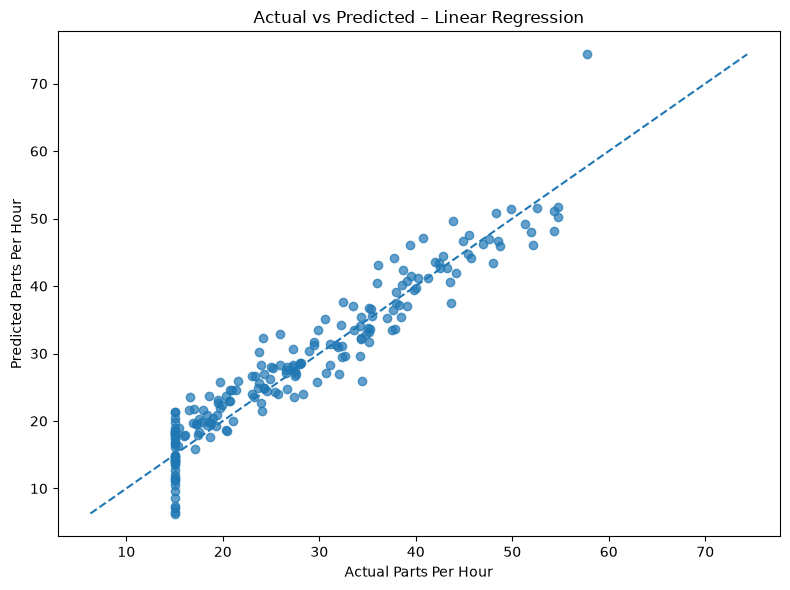

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")
plt.xlabel("Actual Parts Per Hour")
plt.ylabel("Predicted Parts Per Hour")
plt.title("Actual vs Predicted – Linear Regression")
plt.tight_layout()
plt.savefig(FIG_DIR / "actual_vs_predicted_linear_regression.png", dpi=200)
plt.show()

## 5. Residual / error analysis

Residual is defined as:

`Residual = Actual − Predicted`

A useful residual plot should show points scattered around zero without a strong systematic pattern.

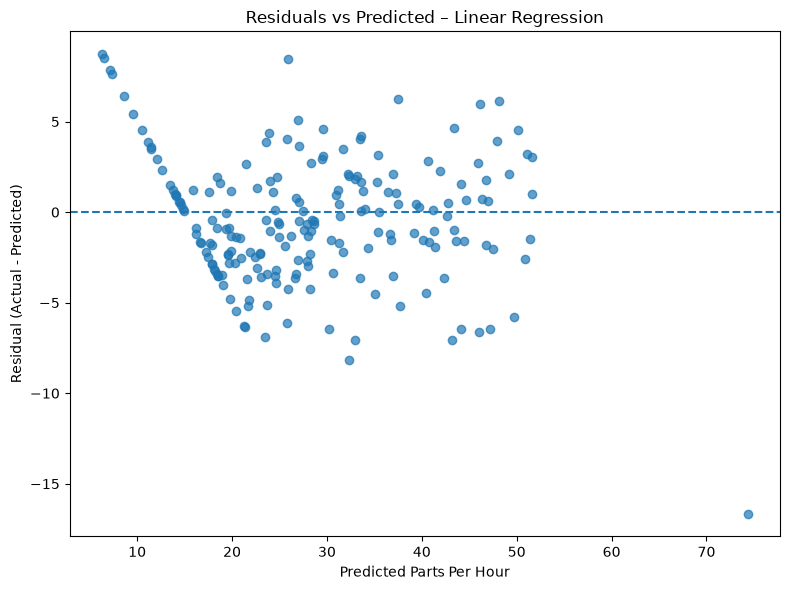

,Residual_Mean,Residual_Std,Minimum_Residual,Maximum_Residual
0,-0.48478,3.474119,-16.644479,8.717554


In [7]:
residuals = y_test.to_numpy() - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Parts Per Hour")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted – Linear Regression")
plt.tight_layout()
plt.savefig(FIG_DIR / "residuals_vs_predicted_linear_regression.png", dpi=200)
plt.show()

residual_summary = pd.DataFrame([{
    "Residual_Mean": residuals.mean(),
    "Residual_Std": residuals.std(),
    "Minimum_Residual": residuals.min(),
    "Maximum_Residual": residuals.max()
}])
residual_summary.to_csv(METRIC_DIR / "residual_summary.csv", index=False)
residual_summary

## 6. Prediction error distribution

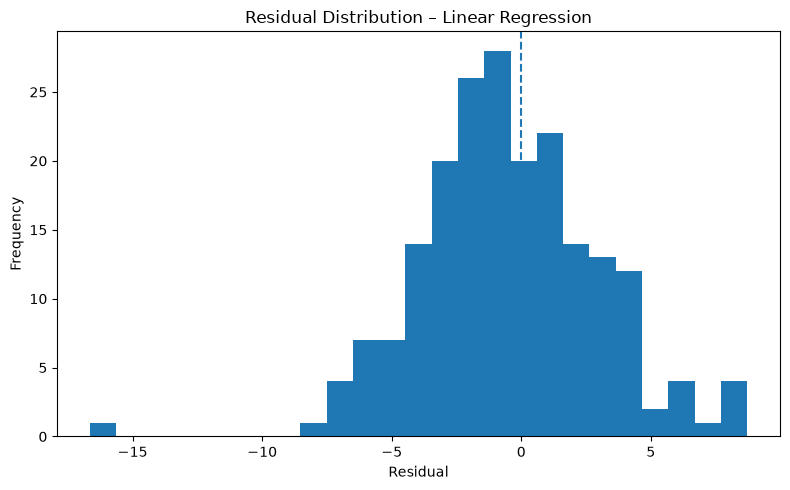

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=25)
plt.axvline(0, linestyle="--")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution – Linear Regression")
plt.tight_layout()
plt.savefig(FIG_DIR / "residual_distribution_linear_regression.png", dpi=200)
plt.show()

## 7. Coefficient analysis

Because numerical predictors are standardized, a numerical coefficient represents the expected change in `Parts_Per_Hour` associated with a **one-standard-deviation increase** in that predictor, holding the other encoded predictors constant.

The categorical variables are one-hot encoded by the current M1 pipeline without `drop="first"`. Therefore, categorical coefficients should **not** be interpreted as clean reference-category effects because the dummy-variable set is redundant with the intercept. This is retained for consistency with M1; changing the encoding requires team agreement.

In [9]:
feature_names = preprocessor.get_feature_names_out()
coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": linear_model.coef_
})
coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values("Absolute_Coefficient", ascending=False)

coefficients.to_csv(METRIC_DIR / "linear_regression_coefficients.csv", index=False)
coefficients.head(15)

,Feature,Coefficient,Absolute_Coefficient
10,numerical__Total_Cycle_Time,-10.047416,10.047416
11,numerical__Efficiency_Score,2.876391,2.876391
3,numerical__Cooling_Time,2.666301,2.666301
0,numerical__Injection_Temperature,2.296038,2.296038
6,numerical__Machine_Age,-2.201767,2.201767
16,categorical__Machine_Type_Type_A,2.115238,2.115238
15,categorical__Shift_Night,-2.062230,2.062230
13,categorical__Shift_Day,1.902766,1.902766
18,categorical__Machine_Type_Type_C,-1.806574,1.806574
19,categorical__Material_Grade_Economy,-1.586562,1.586562


## 8. Test-set predictions

The prediction table is saved so M4/M6/M7 can trace individual test predictions and errors.

In [10]:
prediction_results = X_test.copy()
prediction_results["Actual_Parts_Per_Hour"] = y_test.to_numpy()
prediction_results["Predicted_Parts_Per_Hour"] = y_pred
prediction_results["Residual"] = residuals
prediction_results["Absolute_Error"] = np.abs(residuals)

prediction_results.to_csv(METRIC_DIR / "test_predictions_linear_regression.csv", index=False)
prediction_results.head()

,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Shift,...,Material_Grade,Day_of_Week,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Actual_Parts_Per_Hour,Predicted_Parts_Per_Hour,Residual,Absolute_Error
521,221.5,123.7,40.9,11.0,144.9,24.0,13.0,5.5,42,Evening,...,Economy,Friday,1.790,51.8,0.036,0.107,18.6,19.901926,-1.301926,1.301926
737,226.8,99.0,33.3,13.5,148.2,22.7,4.7,112.4,51,Night,...,Standard,Wednesday,2.291,46.8,0.698,0.510,42.8,44.406342,-1.606342,1.606342
740,192.9,113.4,32.8,13.0,211.1,24.1,14.3,66.2,33,Evening,...,Premium,Wednesday,1.701,45.9,0.461,0.040,34.2,34.049442,0.150558,0.150558
660,208.1,134.8,42.4,12.3,221.8,26.8,4.7,113.4,37,Day,...,Standard,Friday,1.544,54.7,0.770,0.559,40.0,39.688411,0.311589,0.311589
411,201.5,123.3,39.6,8.0,170.8,23.0,12.9,2.2,43,Day,...,Standard,Wednesday,1.634,47.6,0.014,0.108,15.0,18.395272,-3.395272,3.395272


## 9. Save the approved M3 artifacts

For M4, the exact fitted preprocessing object and Linear Regression model are saved separately, plus a combined pipeline. The combined pipeline is the safest artifact for deployment because it preserves preprocessing and prediction in one object.

In [11]:
joblib.dump(preprocessor, MODEL_DIR / "preprocessor.joblib")
joblib.dump(linear_model, MODEL_DIR / "linear_regression_model.joblib")

combined_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", linear_model)
])
joblib.dump(combined_pipeline, MODEL_DIR / "linear_regression_pipeline.joblib")

metadata = {
    "target": "Parts_Per_Hour",
    "model": "LinearRegression",
    "test_size": 0.20,
    "random_state": 42,
    "numerical_features": numerical_columns,
    "categorical_features": categorical_columns,
    "timestamp_handling": "Dropped",
    "numerical_imputation": "Median",
    "categorical_imputation": "Most frequent",
    "categorical_encoding": "OneHotEncoder(handle_unknown='ignore')",
    "numerical_scaling": "StandardScaler",
    "training_rows": int(len(X_train)),
    "testing_rows": int(len(X_test)),
    "processed_feature_count": int(X_train_processed.shape[1])
}
with open(MODEL_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
for p in sorted(MODEL_DIR.iterdir()):
    print("-", p.name)

Saved:
- linear_regression_model.joblib
- linear_regression_pipeline.joblib
- model_metadata.json
- preprocessor.joblib


## 10. M3 conclusion

- The required Linear Regression model is trained and evaluated on the fixed 80/20 split.
- MAE, MSE, RMSE and R² are recorded.
- Actual-vs-predicted and residual plots are saved.
- Coefficients are exported with an explicit scaling/encoding interpretation note.
- Linear Regression is retained as the **approved primary model** for M4 to satisfy the project requirement; Ridge/Lasso are benchmark results only.
- M4 should load `linear_regression_pipeline.joblib` so new inputs receive exactly the same preprocessing as training.